# 04 — RQ2: Logistic Regression for Stage-1 Risk Classification

**Question:** Can a classifier built on Stage-1-observable features predict downstream exception or SLA-breach risk?

**Method:** Logistic regression on the 1,000-case balanced sample. Stratified 5-fold cross-validation; ROC AUC reported with 95% bootstrap CI (Hanley–McNeil-style precision target). EPV ≥ 20 satisfied (Peduzzi et al., 1996).

**Output:** `figures/fig5_roc_cm.png` — ROC curve and confusion matrix.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, roc_curve,
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score)

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
FIG  = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

case = pd.read_csv(PROC / 'case_level_balanced_1000.csv')
print('class balance:', case.risk_flag.value_counts().to_dict())

class balance: {1: 500, 0: 500}


## Feature engineering

Twelve Stage-1-observable features. The model never sees outcome variables (`exception_flag`, `sla_breach_flag`, `stage1_processing_time`).

In [2]:
features = ['completeness_flag', 'submission_channel',
            'product_complexity_index', 'product_type',
            'requested_amount', 'resource_workload',
            'recent_exception_rate', 'customer_segment']
X = case[features].copy()
X['log_amount'] = np.log(X['requested_amount'])
X = X.drop(columns=['requested_amount'])
X = pd.get_dummies(X, drop_first=True).astype(float)
y = case['risk_flag'].values
feature_names = X.columns.tolist()
print('predictor matrix:', X.shape)

predictor matrix: (1000, 12)


## Stratified 5-fold cross-validation

In [3]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X.values)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=2000, C=1.0)
y_proba = cross_val_predict(model, Xs, y, cv=skf, method='predict_proba')[:, 1]
auc = roc_auc_score(y, y_proba)
print(f'CV ROC AUC = {auc:.3f}')

CV ROC AUC = 0.761


## 95% bootstrap CI on AUC

In [4]:
rng = np.random.default_rng(42)
B = 1000
boot = np.zeros(B)
for b in range(B):
    idx = rng.integers(0, len(y), len(y))
    if len(np.unique(y[idx])) < 2:
        boot[b] = np.nan; continue
    boot[b] = roc_auc_score(y[idx], y_proba[idx])
lo, hi = np.nanpercentile(boot, [2.5, 97.5])
print(f'AUC 95% CI: [{lo:.3f}, {hi:.3f}] (half-width {(hi-lo)/2:.3f})')

AUC 95% CI: [0.732, 0.792] (half-width 0.030)


## Confusion matrix and metrics at default 0.50 threshold

In [5]:
y_pred = (y_proba >= 0.50).astype(int)
cm = confusion_matrix(y, y_pred)
print('Confusion matrix [rows actual, cols predicted]:')
print(cm); print()
print(f'Accuracy : {accuracy_score(y, y_pred):.3f}')
print(f'Precision: {precision_score(y, y_pred):.3f}')
print(f'Recall   : {recall_score(y, y_pred):.3f}')
print(f'F1       : {f1_score(y, y_pred):.3f}')

Confusion matrix [rows actual, cols predicted]:
[[363 137]
 [153 347]]

Accuracy : 0.710
Precision: 0.717
Recall   : 0.694
F1       : 0.705


## Figure 5 — ROC curve and confusion matrix

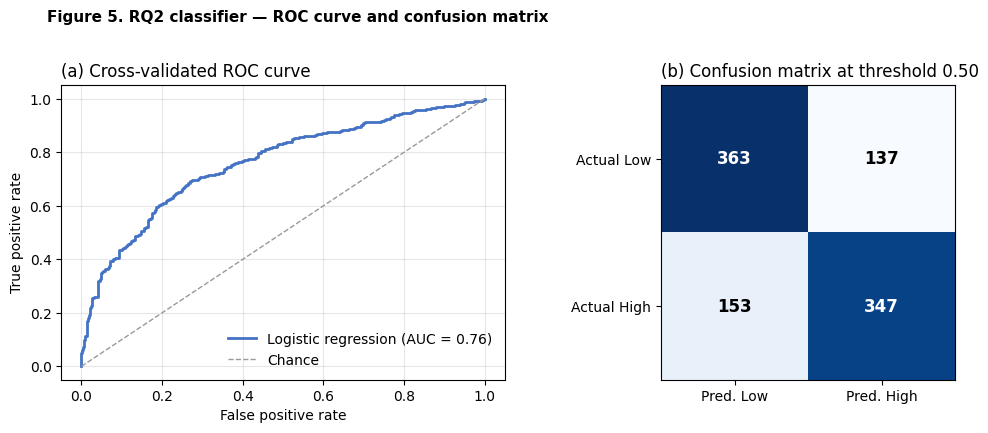

In [6]:
fpr, tpr, _ = roc_curve(y, y_proba)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(fpr, tpr, color='#4472C4', lw=2,
    label=f'Logistic regression (AUC = {auc:.2f})')
axes[0].plot([0,1],[0,1], '--', color='#999', lw=1, label='Chance')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('(a) Cross-validated ROC curve', loc='left')
axes[0].legend(frameon=False, loc='lower right'); axes[0].grid(alpha=0.3)
axes[1].imshow(cm, cmap='Blues'); axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Pred. Low','Pred. High'])
axes[1].set_yticklabels(['Actual Low','Actual High'])
for i in range(2):
    for j in range(2):
        c = 'white' if cm[i,j] > cm.max()/2 else 'black'
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center',
                     color=c, fontsize=12, fontweight='bold')
axes[1].set_title('(b) Confusion matrix at threshold 0.50', loc='left')
axes[1].grid(False)
fig.suptitle('Figure 5. RQ2 classifier — ROC curve and confusion matrix',
    x=0.05, y=1.02, ha='left', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'fig5_roc_cm.png', dpi=160,
    bbox_inches='tight'); plt.show()

## Top-2 most decision-useful operational signals (RQ2 deliverable)

Standardized log-odds coefficients identify the strongest predictors.

In [7]:
model.fit(Xs, y)
coefs = pd.DataFrame({'feature': feature_names, 'coef': model.coef_[0]})
coefs['abs_coef'] = coefs['coef'].abs()
coefs = coefs.sort_values('abs_coef', ascending=False)
print('Top 5 standardized predictors:')
print(coefs.head().to_string(index=False))

Top 5 standardized predictors:
                   feature      coef  abs_coef
     recent_exception_rate  0.803517  0.803517
         completeness_flag -0.516550  0.516550
         resource_workload  0.476449  0.476449
    submission_channel_web  0.328014  0.328014
submission_channel_partner  0.134353  0.134353
